# $\Omega_\eta$ tracing vs bounce RMSE

Compare QA, QH, and QI from `data_v2`. For each configuration: average $\Omega_\eta$ over $\alpha$ (BA and GC separately), RMSE over $B_{\rm crit}$ ($\kappa$) to form $R^{\mathrm{GC}}$ and $R^{\mathrm{BA}}$, RMSE those over $s$, then plot $|R^{\mathrm{GC}}-R^{\mathrm{BA}}|/\overline{\Omega}_\eta$. QI low-$E$ and higher-$E$ scans are merged along energy. One curve per configuration.


In [1]:
import matplotlib.pyplot as plt

FontSize = 28
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8),
    }
)

PANEL_FIGSIZE = (6.0, 5.0)
PANEL_RECT = [0.20, 0.20, 0.78, 0.75]

YLABEL = (
    r"$\left|\Omega_\eta^{\mathrm{GC}}-\Omega_\eta^{\mathrm{BA}}\right|/\,\overline{\Omega_\eta}$"
)

CONFIG_LABELS = {"QA": "QA", "QH": "QH", "QI": "QI"}


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path(".").resolve()
DATA = HERE / "data_v2_Bcritsurf/"  # Omega_eta(s, alpha, kappa, energy) for BA and GC


def _average_over_alpha(omega):
    """data_v2 is (s, alpha, kappa, energy); collapse alpha -> (s, kappa, energy)."""
    omega = np.asarray(omega, float)
    if omega.ndim == 4:
        return np.mean(omega, axis=1)
    if omega.ndim == 3:
        return omega
    raise ValueError(f"unexpected omega ndim={omega.ndim}, shape={omega.shape}")


def load_omega(path):
    """Load BA/GC Omega_eta, averaging over alpha first when present."""
    d = np.load(path, allow_pickle=True)
    return {
        "fractions": np.asarray(d["fractions"], float),
        "s_values": np.asarray(d["s_values"], float),
        "omega_gc": _average_over_alpha(d["omega_tracing"]),
        "omega_ba": _average_over_alpha(d["omega_bounce"]),
        "eq_name": str(d["eq_name"]),
    }


def rmse_over_axes(arr, axes):
    """RMSE of arr over the given axes."""
    return np.sqrt(np.mean(np.asarray(arr, float) ** 2, axis=axes))


def rmse_norm_from_omega(omega_gc, omega_ba):
    """RMSE_kappa, then RMSE_s for GC and BA separately; then |R_GC - R_BA| / mean.

    Returns shape (n_energy,).
    """
    # omega_*: (s, kappa, energy)
    R_gc = rmse_over_axes(omega_gc, 1)  # over kappa -> (s, energy)
    R_ba = rmse_over_axes(omega_ba, 1)
    R_gc = rmse_over_axes(R_gc, 0)  # over s -> (energy,)
    R_ba = rmse_over_axes(R_ba, 0)
    omega_bar = 0.5 * (R_gc + R_ba)
    return np.abs(R_gc - R_ba) / omega_bar


def merge_omega_scans(datasets):
    """Concatenate omega scans that share the same s-grid along energy."""
    s_values = datasets[0]["s_values"]
    for ds in datasets[1:]:
        if not np.allclose(ds["s_values"], s_values):
            raise ValueError("s_values do not match across datasets")
    fractions = np.concatenate([ds["fractions"] for ds in datasets])
    omega_gc = np.concatenate([ds["omega_gc"] for ds in datasets], axis=2)
    omega_ba = np.concatenate([ds["omega_ba"] for ds in datasets], axis=2)
    order = np.argsort(fractions)
    return {
        "fractions": fractions[order],
        "s_values": s_values,
        "omega_gc": omega_gc[:, :, order],
        "omega_ba": omega_ba[:, :, order],
    }


def config_rmse_norm(key):
    """Return (fractions, rmse_norm) for QA, QH, or QI (QI merges lowE + highE)."""
    if key == "QI":
        ds = merge_omega_scans([
            load_omega(DATA / "omega_eta_tracing_vs_bounce_QI_lowE.npz"),
            load_omega(DATA / "omega_eta_tracing_vs_bounce_QI.npz"),
        ])
    else:
        ds = load_omega(DATA / f"omega_eta_tracing_vs_bounce_{key}.npz")
    return ds["fractions"], rmse_norm_from_omega(ds["omega_gc"], ds["omega_ba"])


def load_omega_raw(path):
    """Load BA/GC Omega_eta without reducing alpha: (s, alpha, kappa, energy)."""
    d = np.load(path, allow_pickle=True)
    omega_gc = np.asarray(d["omega_tracing"], float)
    omega_ba = np.asarray(d["omega_bounce"], float)
    if omega_gc.ndim != 4 or omega_ba.ndim != 4:
        raise ValueError(
            f"expected (s, alpha, kappa, energy); got GC {omega_gc.shape}, BA {omega_ba.shape}"
        )
    return {
        "fractions": np.asarray(d["fractions"], float),
        "s_values": np.asarray(d["s_values"], float),
        "omega_gc": omega_gc,
        "omega_ba": omega_ba,
        "eq_name": str(d["eq_name"]),
    }


def merge_omega_scans_raw(datasets):
    """Concatenate raw 4D omega scans along energy (axis 3)."""
    s_values = datasets[0]["s_values"]
    for ds in datasets[1:]:
        if not np.allclose(ds["s_values"], s_values):
            raise ValueError("s_values do not match across datasets")
        if ds["omega_gc"].shape[:3] != datasets[0]["omega_gc"].shape[:3]:
            raise ValueError("s/alpha/kappa grids do not match across datasets")
    fractions = np.concatenate([ds["fractions"] for ds in datasets])
    omega_gc = np.concatenate([ds["omega_gc"] for ds in datasets], axis=3)
    omega_ba = np.concatenate([ds["omega_ba"] for ds in datasets], axis=3)
    order = np.argsort(fractions)
    return {
        "fractions": fractions[order],
        "s_values": s_values,
        "omega_gc": omega_gc[:, :, :, order],
        "omega_ba": omega_ba[:, :, :, order],
    }


def rmse_norm_bcrit_then_alpha(omega_gc, omega_ba):
    """RMSE_kappa first, then mean_alpha, then RMSE_s; then |R_GC - R_BA| / mean.

    omega_*: (s, alpha, kappa, energy) -> Y(energy).
    """
    # axis 2 = kappa / Bcrit
    R_gc = rmse_over_axes(omega_gc, 2)  # (s, alpha, energy)
    R_ba = rmse_over_axes(omega_ba, 2)
    R_gc = np.mean(R_gc, axis=1)  # average over alpha -> (s, energy)
    R_ba = np.mean(R_ba, axis=1)
    R_gc = rmse_over_axes(R_gc, 0)  # over s -> (energy,)
    R_ba = rmse_over_axes(R_ba, 0)
    omega_bar = 0.5 * (R_gc + R_ba)
    return np.abs(R_gc - R_ba) / omega_bar


def config_rmse_norm_bcrit_then_alpha(key):
    """Like config_rmse_norm, but RMSE over Bcrit before averaging alpha."""
    if key == "QI":
        ds = merge_omega_scans_raw([
            load_omega_raw(DATA / "omega_eta_tracing_vs_bounce_QI_lowE.npz"),
            load_omega_raw(DATA / "omega_eta_tracing_vs_bounce_QI.npz"),
        ])
    else:
        ds = load_omega_raw(DATA / f"omega_eta_tracing_vs_bounce_{key}.npz")
    return ds["fractions"], rmse_norm_bcrit_then_alpha(ds["omega_gc"], ds["omega_ba"])


## Exact $y$-axis definition (same for every configuration)

For a fixed configuration (QA, QH, or QI), the stored arrays are

$$
\Omega_\eta^{\mathrm{GC}}(s_i,\alpha_j,\kappa_k,E_n),\qquad
\Omega_\eta^{\mathrm{BA}}(s_i,\alpha_j,\kappa_k,E_n),
$$

with indices \(i=1,\ldots,N_s\), \(j=1,\ldots,N_\alpha\), \(k=1,\ldots,N_\kappa\), \(n=1,\ldots,N_E\).
Here \(\kappa\) labels the trapped-particle \(B_{\rm crit}\) samples. QI concatenates the low-\(E\) and higher-\(E\) scans along \(n\) (sorted by energy fraction) before the steps below; QA and QH already span the full energy grid.

### Step 1 — arithmetic mean over field-line label \(\alpha\)

Done **separately** for GC and BA (no mixing of the two models):

$$
\big\langle\Omega_\eta^{\mathrm{GC}}\big\rangle_\alpha(s_i,\kappa_k,E_n)
=
\frac{1}{N_\alpha}\sum_{j=1}^{N_\alpha}
\Omega_\eta^{\mathrm{GC}}(s_i,\alpha_j,\kappa_k,E_n),
$$

and likewise for \(\langle\Omega_\eta^{\mathrm{BA}}\rangle_\alpha\). After this step the arrays are shape \((N_s,N_\kappa,N_E)\).

### Step 2 — RMSE over \(B_{\rm crit}\) (\(\kappa\)), at fixed \(s\) and \(E\)

$$
R^{\mathrm{GC}}(s_i,E_n)
=
\sqrt{
\frac{1}{N_\kappa}\sum_{k=1}^{N_\kappa}
\big\langle\Omega_\eta^{\mathrm{GC}}\big\rangle_\alpha(s_i,\kappa_k,E_n)^{\,2}
},
$$

$$
R^{\mathrm{BA}}(s_i,E_n)
=
\sqrt{
\frac{1}{N_\kappa}\sum_{k=1}^{N_\kappa}
\big\langle\Omega_\eta^{\mathrm{BA}}\big\rangle_\alpha(s_i,\kappa_k,E_n)^{\,2}
}.
$$

Shape after this step: \((N_s,N_E)\).

### Step 3 — RMSE over flux surfaces \(s\) (separately for GC and BA)

$$
R^{\mathrm{GC}}(E_n)
=
\sqrt{
\frac{1}{N_s}\sum_{i=1}^{N_s}
\big[R^{\mathrm{GC}}(s_i,E_n)\big]^2
},
$$

$$
R^{\mathrm{BA}}(E_n)
=
\sqrt{
\frac{1}{N_s}\sum_{i=1}^{N_s}
\big[R^{\mathrm{BA}}(s_i,E_n)\big]^2
}.
$$

Shape after this step: \((N_E,)\).

### Step 4 — relative difference of the collapsed RMSEs

$$
\overline{\Omega}_\eta(E_n)
=
\frac{1}{2}\Big(R^{\mathrm{GC}}(E_n)+R^{\mathrm{BA}}(E_n)\Big),
$$

$$
Y(E_n)
=
\frac{\big|R^{\mathrm{GC}}(E_n)-R^{\mathrm{BA}}(E_n)\big|}{\overline{\Omega}_\eta(E_n)}.
$$

### What is plotted

For each configuration, the curve is \(\bigl(E_n/E_\alpha,\; Y(E_n)\bigr)\) on a log \(x\)-axis. The three configurations use the same four steps; only the underlying \(\Omega_\eta\) arrays differ.


QA fractions: [1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00]
QA y: [1.96126768e-04 3.42563960e-04 8.80295732e-04 2.38703103e-03
 6.66999034e-03 2.28201722e-02 7.47226954e-02 3.36114611e-01]
QH fractions: [1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00]
QH y: [1.03862663e-04 2.57516639e-05 1.70326996e-04 5.06312610e-04
 1.59246223e-03 1.79279665e-02 3.36646231e-02 8.70079266e-02]
QI fractions: [1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00]
QI y: [0.00159371 0.00258751 0.00817974 0.03392128 0.12484757 0.08932912
 0.041798   0.07019776]


findfont: Failed to find font weight normal, now using 0.


wrote /Users/paullab/Papers/TRObj2026/Omega_eta_tracing_vs_bounce/forpaper/omega_eta_tracing_vs_bounce_QA_QH_QI_rmse_norm.pdf


(<Figure size 600x500 with 1 Axes>,
 <Axes: xlabel='Fraction of $\\alpha$ Energy', ylabel='$\\left|\\Omega_\\eta^{\\mathrm{GC}}-\\Omega_\\eta^{\\mathrm{BA}}\\right|/\\,\\overline{\\Omega_\\eta}$'>)

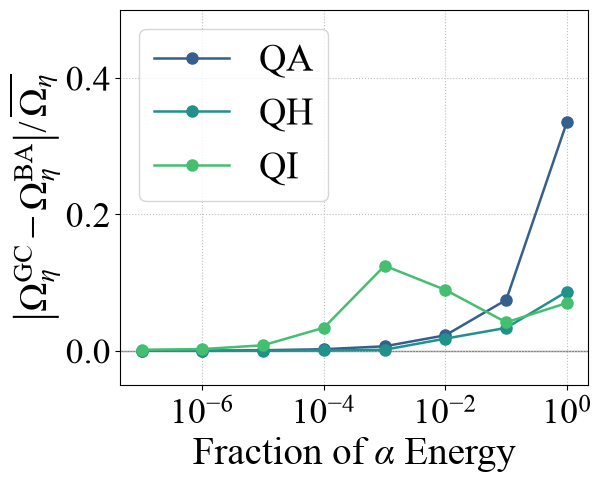

In [3]:
# Single plot: QA, QH, QI on one axis

configs = ("QA", "QH", "QI")
colors = {
    "QA": plt.cm.viridis(0.30),
    "QH": plt.cm.viridis(0.50),
    "QI": plt.cm.viridis(0.70),
}

fig = plt.figure(figsize=PANEL_FIGSIZE)
ax = fig.add_axes(PANEL_RECT)

for key in configs:
    fractions, rmse_norm = config_rmse_norm(key)
    ax.plot(
        fractions,
        rmse_norm,
        "o-",
        color=colors[key],
        markersize=8,
        linewidth=1.8,
        label=CONFIG_LABELS[key],
    )
    print(key, "fractions:", fractions)
    print(key, "y:", rmse_norm)

ax.axhline(0.0, color="0.5", linewidth=1.0, zorder=0)
ax.set_xscale("log")
ax.set_xlabel(r"Fraction of $\alpha$ Energy", **label_kw)
ax.set_ylabel(YLABEL, **label_kw)
ax.set_ylim(-0.05, 0.50)
ax.xaxis.grid(True, which="major", linestyle=":", color="0.75", linewidth=0.8)
ax.yaxis.grid(True, which="both", linestyle=":", color="0.75", linewidth=0.8)
ax.tick_params(labelsize=tick_labelsize)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
ax.legend(
    loc="upper left",
    frameon=True,
    prop={"family": "Times New Roman", "size": FontSize - 1},
)
ax.set_position(PANEL_RECT)

out_dir = HERE / "forpaper"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "omega_eta_tracing_vs_bounce_QA_QH_QI_rmse_norm.pdf"
fig.savefig(out_path, dpi=300, bbox_inches=None, pad_inches=0)
print(f"wrote {out_path}")
fig, ax


## Alternate reduction: RMSE over $B_{\rm crit}$, then mean over $\alpha$, then RMSE over $s$

Same final comparison $|R^{\mathrm{GC}}-R^{\mathrm{BA}}|/\overline{\Omega}_\eta$, but the reductions run in a different order. Starting from
$\Omega_\eta^{\mathrm{GC/BA}}(s_i,\alpha_j,\kappa_k,E_n)$:

### Step 1 — RMSE over $B_{\rm crit}$ ($\kappa$), at fixed $s$, $\alpha$, and $E$

$$
R^{\mathrm{GC}}(s_i,\alpha_j,E_n)
=
\sqrt{
\frac{1}{N_\kappa}\sum_{k=1}^{N_\kappa}
\Omega_\eta^{\mathrm{GC}}(s_i,\alpha_j,\kappa_k,E_n)^{\,2}
},
$$

and likewise for $R^{\mathrm{BA}}$. Shape: $(N_s,N_\alpha,N_E)$.

### Step 2 — arithmetic mean over $\alpha$

$$
R^{\mathrm{GC}}(s_i,E_n)
=
\frac{1}{N_\alpha}\sum_{j=1}^{N_\alpha} R^{\mathrm{GC}}(s_i,\alpha_j,E_n),
$$

and likewise for $R^{\mathrm{BA}}$. Shape: $(N_s,N_E)$.

### Step 3 — RMSE over $s$

$$
R^{\mathrm{GC}}(E_n)
=
\sqrt{\frac{1}{N_s}\sum_{i=1}^{N_s}\big[R^{\mathrm{GC}}(s_i,E_n)\big]^2},
\qquad
R^{\mathrm{BA}}(E_n)
=
\sqrt{\frac{1}{N_s}\sum_{i=1}^{N_s}\big[R^{\mathrm{BA}}(s_i,E_n)\big]^2}.
$$

### Step 4 — relative difference

$$
\overline{\Omega}_\eta(E_n)=\tfrac12\big(R^{\mathrm{GC}}(E_n)+R^{\mathrm{BA}}(E_n)\big),
\qquad
Y(E_n)=\frac{\big|R^{\mathrm{GC}}(E_n)-R^{\mathrm{BA}}(E_n)\big|}{\overline{\Omega}_\eta(E_n)}.
$$


QA fractions: [1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00]
QA y: [1.90600235e-04 3.41081137e-04 8.79140303e-04 2.38376098e-03
 6.66165782e-03 2.27784827e-02 7.47927205e-02 3.37072988e-01]
QH fractions: [1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00]
QH y: [1.04882068e-04 2.35630356e-05 1.70694327e-04 5.07185920e-04
 1.59723566e-03 1.79428867e-02 3.36864944e-02 8.70397084e-02]
QI fractions: [1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00]
QI y: [0.00158897 0.00260441 0.00830001 0.034785   0.12870931 0.0894442
 0.04320946 0.07076851]
wrote /Users/paullab/Papers/TRObj2026/Omega_eta_tracing_vs_bounce/forpaper/omega_eta_tracing_vs_bounce_QA_QH_QI_rmse_norm_bcrit_then_alpha.pdf


(<Figure size 600x500 with 1 Axes>,
 <Axes: xlabel='Fraction of $\\alpha$ Energy', ylabel='$\\left|\\Omega_\\eta^{\\mathrm{GC}}-\\Omega_\\eta^{\\mathrm{BA}}\\right|/\\,\\overline{\\Omega_\\eta}$'>)

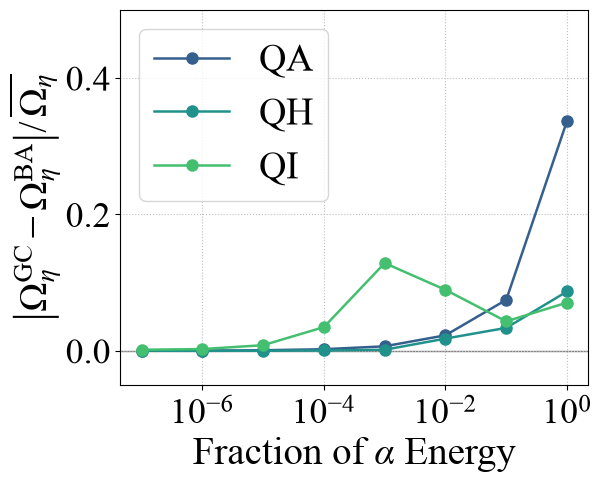

In [27]:
# Alternate plot: RMSE_Bcrit -> mean_alpha -> RMSE_s, then |R_GC - R_BA|/Ω̄

configs = ("QA", "QH", "QI")
colors = {
    "QA": plt.cm.viridis(0.30),
    "QH": plt.cm.viridis(0.50),
    "QI": plt.cm.viridis(0.70),
}

fig = plt.figure(figsize=PANEL_FIGSIZE)
ax = fig.add_axes(PANEL_RECT)

for key in configs:
    fractions, y = config_rmse_norm_bcrit_then_alpha(key)
    ax.plot(
        fractions,
        y,
        "o-",
        color=colors[key],
        markersize=8,
        linewidth=1.8,
        label=CONFIG_LABELS[key],
    )
    print(key, "fractions:", fractions)
    print(key, "y:", y)

ax.axhline(0.0, color="0.5", linewidth=1.0, zorder=0)
ax.set_xscale("log")
ax.set_xlabel(r"Fraction of $\alpha$ Energy", **label_kw)
ax.set_ylabel(YLABEL, **label_kw)
ax.set_ylim(-0.05, 0.50)
ax.xaxis.grid(True, which="major", linestyle=":", color="0.75", linewidth=0.8)
ax.yaxis.grid(True, which="both", linestyle=":", color="0.75", linewidth=0.8)
ax.tick_params(labelsize=tick_labelsize)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
ax.legend(
    loc="upper left",
    frameon=True,
    prop={"family": "Times New Roman", "size": FontSize - 1},
)
ax.set_position(PANEL_RECT)

out_dir = HERE / "forpaper"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "omega_eta_tracing_vs_bounce_QA_QH_QI_rmse_norm_bcrit_then_alpha.pdf"
fig.savefig(out_path, dpi=300, bbox_inches=None, pad_inches=0)
print(f"wrote {out_path}")
fig, ax
